# 02 Baseline models: floors and linear

**Purpose.** Establish the floor and the first real result in the Phase 3 model ladder
(`docs/plan.md`): two trivial baselines, then logistic regression with and without splines and
interactions. The full sweep lives in `src/fraud/models/run_ladder.py` / `tune.py`; this notebook
only loads and presents its results (`reports/model_ladder.json`) plus a couple of live checks on
validation.

**Primary metric.** Recall at precision >= 0.50 on validation (CLAUDE.md's false-alarm budget: at
most one false alarm per caught fraud). PR-AUC is secondary. Test split is never opened here.

In [1]:
import json

import matplotlib.pyplot as plt
import pandas as pd

from fraud.params import REPO_ROOT

SURFACE, INK, INK2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e6e5e1"
LEGIT, FRAUD = "#2a78d6", "#eb6834"
plt.rcParams.update(
    {
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "savefig.facecolor": SURFACE,
        "text.color": INK,
        "axes.labelcolor": INK,
        "xtick.color": INK2,
        "ytick.color": INK2,
        "axes.edgecolor": GRID,
        "grid.color": GRID,
        "font.size": 11,
    }
)

ladder = pd.DataFrame(json.loads((REPO_ROOT / "reports" / "model_ladder.json").read_text()))
baselines = ladder[ladder["step_id"] <= 2].sort_values("step_id")
baselines[
    [
        "step_id",
        "key",
        "name",
        "feature_set",
        "recall_at_precision",
        "precision_at_threshold",
        "pr_auc",
        "met_budget",
    ]
]

,step_id,key,name,feature_set,recall_at_precision,precision_at_threshold,pr_auc,met_budget
0,0,amount_rule,Amount-rule heuristic,v1,0.000000,1.0,0.153313,False
1,0,dummy,Dummy (always legit),v1,0.000000,1.0,0.004407,False
2,1,logreg,"Logistic regression (L2, scaled)",v1,0.312268,0.5,0.265179,True
3,2,logreg_interact,Logistic regression + splines/interactions,v1,0.265799,0.5,0.292497,True


## 1. The floor: dummy and the amount-rule heuristic

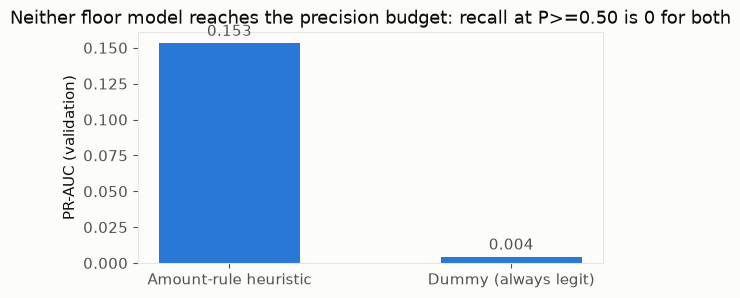

In [2]:
floor = baselines[baselines["step_id"] == 0]
fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(floor["name"], floor["pr_auc"], color=LEGIT, width=0.5)
ax.set_ylabel("PR-AUC (validation)")
ax.set_title("Neither floor model reaches the precision budget: recall at P>=0.50 is 0 for both")
for i, (_, row) in enumerate(floor.iterrows()):
    ax.text(i, row["pr_auc"] + 0.005, f"{row['pr_auc']:.3f}", ha="center", color=INK2)
plt.show()

## 2. Logistic regression, with and without splines/interactions

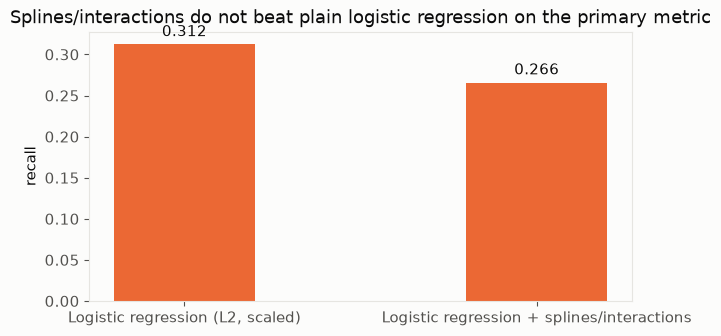

,name,hyperparams,recall_at_precision,pr_auc
2,"Logistic regression (L2, scaled)",{'C': 0.0011833253552609156},0.312268,0.265179
3,Logistic regression + splines/interactions,"{'C': 0.001267425589893723, 'n_knots': 8}",0.265799,0.292497


In [3]:
linear = baselines[baselines["step_id"].isin([1, 2])]
fig, ax = plt.subplots(figsize=(7, 3.5))
x = range(len(linear))
ax.bar(x, linear["recall_at_precision"], color=FRAUD, width=0.4, label="recall @ P>=0.50")
ax.set_xticks(list(x))
ax.set_xticklabels(linear["name"], rotation=0)
ax.set_ylabel("recall")
ax.set_title("Splines/interactions do not beat plain logistic regression on the primary metric")
for i, (_, row) in enumerate(linear.iterrows()):
    ax.text(i, row["recall_at_precision"] + 0.01, f"{row['recall_at_precision']:.3f}", ha="center")
plt.show()

linear[["name", "hyperparams", "recall_at_precision", "pr_auc"]]

## 3. Conclusions

**The floor is exactly zero, as designed.** The dummy classifier (always legit) and the amount-rule
heuristic both fail to reach a 50% precision threshold at any positive recall: their only real
operating point (flag transactions above some amount) never gets precision above 15% at usable
recall, so `recall_at_precision` reports 0 for both, with the trivial "flag nothing" fallback taken
instead (see `fraud.models.metrics.recall_at_precision`). The amount-rule's PR-AUC (0.153) is still
far above the dummy's (0.004) — amount alone carries real signal, just not enough to clear the
budget alone.

**Logistic regression is the first model to clear the budget**: recall 0.312 at precision 0.50,
PR-AUC 0.265, with a small C (~0.0012, from Optuna) suggesting the tuner Favours strong
regularisation for a model this simple on 74 features.

**Splines and interactions do not earn their added complexity.** Recall drops to 0.266 despite the
PR-AUC rising to 0.292 — a good illustration of why the ladder protocol scores by recall at a fixed
precision rather than by AUC alone: a model can rank better in aggregate while doing worse at the
exact operating point that matters. This rung does not survive the ladder's "must beat the previous
rung" rule, and the next step (03_models) moves straight to non-linear models.